In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.data_utils import main_load_data
from cns.utils.assemblies import hg19
from cns.utils.selection import select_CNS_samples, sample_head

## Load source files

In [6]:
samples, cns = main_load_data()
datasets = list(samples["source"].unique())
datasets

['PCAWG', 'TRACERx', 'TCGA_hg19']

In [7]:
def get_table(subsample):
    total = len(subsample)
    table = []
    for i in range(0, subsample["breaks_aut"].max()):
        sample = subsample[subsample["breaks_aut"] >= i].shape[0]
        table.append([i, sample, sample / total * 100])

    table = pd.DataFrame(table, columns=["threshold", "samples", "percentage"])
    return table

Text(0.5, 0.98, 'Percentage of samples with $n$ breaks')

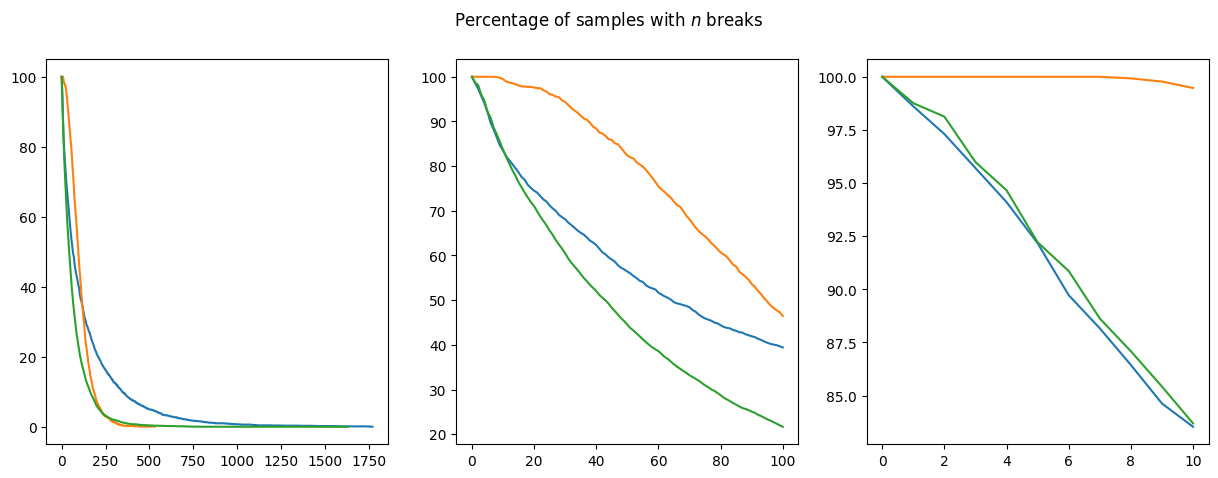

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # Create a figure and a 1x3 subplot
for dataset in datasets:
    table = get_table(samples.query(f"source == '{dataset}'"))

    axs[0].plot(table["threshold"], table["percentage"])   

    selection = table[table["threshold"] <=100]  
    axs[1].plot(selection["threshold"], selection["percentage"])

    selection = table[table["threshold"] <=10]  
    axs[2].plot(selection["threshold"], selection["percentage"])

plt.suptitle("Percentage of samples with $n$ breaks")